In [1]:
from cluster_paths import get_cluster_paths
scratch_path, repo_path = get_cluster_paths()

%load_ext autoreload
%autoreload 2

import h5py, os, yaml
import numpy as np
import healpy as hp
from tqdm import tqdm

import tensorflow as tf
for gpu in tf.config.list_physical_devices(device_type="GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

from msfm.utils import files, observation, buzzard, catalog, parameters

from deep_lss.models.base_model import BaseModel
from deep_lss.utils import configuration, evaluation
from deep_lss.nets import NETWORKS

from msi.utils import preprocessing


2026-05-15 08:59:48.530020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 08:59:48.538842: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-15 08:59:48.542832: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/users/athomsen/dlss/tf_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# v16

In [2]:
# Perlmutter
# data_dir = f"{scratch_path}/v11desy3/v16/default"
# base_dir = f"{scratch_path}/deep_lss/v16/default/maps"

# Clariden
# subversion = "default"
# subversion = "no_sc"
subversion = "rot_in_place"
data_dir = f"{scratch_path}/deep_lss/data/v16/{subversion}"
base_dir = f"{scratch_path}/deep_lss/runs/v16/{subversion}/maps"


In [3]:
# probe = "lensing"

# model_name = "v5"
# n_steps = 360_000

# # model_name = "v1"
# # n_steps = 400_000


In [4]:
# probe = "clustering"

# # model_name = "v5"
# # # n_steps = 130_000
# # n_steps = 180_000

# # model_name = "v5"
# # # n_steps = 130_000
# # n_steps = 180_000

# # model_name = "v1"
# # n_steps = 230_000

# model_name = "40Mpc"
# n_steps = 390_000


In [5]:
probe = "combined"

# model_name = "v1"
# n_steps = 150_000

# https://wandb.ai/eth-cosmo/y3-deep-lss/runs/7c4l5w5k
model_name = "v1"
# n_steps = 150_000
# n_steps = 200_000
n_steps = 250_000


# network

In [6]:
model_dir = os.path.join(base_dir, probe, model_name)

# configs
with open(os.path.join(model_dir, "configs.yaml"), "r") as f:
    net_conf, dlss_conf, msfm_conf = list(yaml.load_all(f, Loader=yaml.FullLoader))
data_vec_pix = files.load_pixel_file(msfm_conf)[0]

# smooth_nside: downsample before HealpySmoothing if configured in the network config
n_side = msfm_conf["analysis"]["n_side"]
smooth_nside = net_conf["network"].get("smooth_nside", None)
if smooth_nside is not None and smooth_nside < n_side:
    smooth_indices, parent_output_idx = configuration.get_smooth_nside_indices(data_vec_pix, n_side, smooth_nside)
    n_pix_out = len(smooth_indices)
    counts = np.bincount(parent_output_idx, minlength=n_pix_out).astype(np.float32)
    def downsample_map(maps):
        # maps: (batch, n_pix_in, n_channels) → (batch, n_pix_out, n_channels)
        result = np.zeros((maps.shape[0], n_pix_out, maps.shape[2]), dtype=maps.dtype)
        np.add.at(result, (slice(None), parent_output_idx, slice(None)), maps)
        return result / counts[np.newaxis, :, np.newaxis]
else:
    smooth_nside = n_side
    smooth_indices = data_vec_pix
    def downsample_map(maps):
        return maps

# constants
with_lensing = dlss_conf["dset"]["common"]["with_lensing"]
with_clustering = dlss_conf["dset"]["common"]["with_clustering"]
params = dlss_conf["dset"]["training"]["params"]
out_features =  len(params) * dlss_conf["mutual_info_loss"]["dim_summary_fac"]

n_z_lensing = len(msfm_conf["survey"]["metacal"]["z_bins"])
n_z_clustering = len(msfm_conf["survey"]["maglim"]["z_bins"])
n_z = 0
if with_lensing:
    n_z += n_z_lensing
if with_clustering:
    n_z += n_z_clustering

# smoothing
smoothing_kwargs = configuration.get_smoothing_kwargs(
    net_conf["run"]["loss_func"], msfm_conf, dlss_conf, net_conf, dir_base="."
)
smoothing_kwargs["max_batch_size"] = 1

# load the layers
network = NETWORKS[net_conf["network"]["name"]](
    out_features=out_features, smoothing_kwargs=smoothing_kwargs, **net_conf["network"]["kwargs"]
).get_layers()

# build the model, same regardless of the loss function (fiducial or grid)
model = BaseModel(
    network=network,
    n_side=smooth_nside,
    indices=smooth_indices,
    n_neighbors=net_conf["network"]["n_neighbors"],
    input_shape=(None, len(smooth_indices), n_z),
    checkpoint_dir=os.path.join(model_dir, "checkpoint"),
    max_batch_size=64,
    restore_checkpoint=False,
    strategy=None,
)

# for manual control over the checkpoint, to match the evaluated grid
checkpoint_number = n_steps // net_conf["training"]["checkpoint_every"]
model.restore_model_from_checkpoint_path(
    os.path.join(model_dir, "checkpoint", f"ckpt-{checkpoint_number}")
)

2026-05-15 08:59:58.554874: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 92614 MB memory:  -> device: 0, name: NVIDIA GH200 120GB, pci bus id: 0009:01:00.0, compute capability: 9.0
2026-05-15 08:59:58.556184: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 92614 MB memory:  -> device: 1, name: NVIDIA GH200 120GB, pci bus id: 0019:01:00.0, compute capability: 9.0
2026-05-15 08:59:58.557407: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 92614 MB memory:  -> device: 2, name: NVIDIA GH200 120GB, pci bus id: 0029:01:00.0, compute capability: 9.0
2026-05-15 08:59:58.558600: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 92616 MB memory:  -> device: 3, name: NVIDIA GH200 120GB, pci bus id: 0039:0

Using the per channel smoothing repetitions [  6   3   2   1 107  50  30  21]
Using the per channel smoothing scales sigma = [13.11  9.27  7.57  5.35 55.35 37.84 29.31 24.52] arcmin, fwhm = [ 30.86  21.82  17.82  12.6  130.34  89.1   69.01  57.74] arcmin
Successfully loaded sparse kernel indices and values from ./smoothing
Successfully created the sparse kernel tensor
Adding white noise with sigma [0.03520349 0.02952409 0.02803563 0.02272882 0.85135    0.34375
 0.25989    0.24127   ] to the smoothed map
26-05-15 08:59:59 regression_h INF   Using a dense regression head 
26-05-15 08:59:59 regression_h WAR   Using dropout with probability 0.01 in the regression head 
26-05-15 08:59:59 base_model.p INF   Initializing with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Successfully built the smoothing layer
Tracing... Due to tensor size, tf

In [7]:
pred_file = os.path.join(model_dir, f"preds_{n_steps}.h5")
print("pred_file =", pred_file, "\n")

_, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    model_dir,
    n_steps=n_steps,
    with_fidu=False,
)


pred_file = /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v1/preds_250000.h5 

26-05-15 09:00:02 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v1/preds_250000.h5 
26-05-15 09:00:02 input_output INF   Array shapes: 
26-05-15 09:00:02 input_output WAR   Could not find fiducial/vali/pred in /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v1/preds_250000.h5 
26-05-15 09:00:02 input_output WAR   Could not find fiducial/vali/i_signal in /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v1/preds_250000.h5 
26-05-15 09:00:02 input_output WAR   Could not find fiducial/vali/i_noise in /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v1/preds_250000.h5 
26-05-15 09:00:02 input_output INF   grid/preds/test    = (2500, 80, 20) 
26-05-15 09:00:02 input_output INF   grid/cosmos/test   = (2500, 80, 10) 
26-05-15 09

# evaluation

## CosmoGrid

### grid

In [8]:
n_examples = 4

for i_grid in range(n_examples):
    # unique cosmological parameters
    i_grid *= msfm_conf["analysis"]["grid"]["n_perms_per_cosmo"] * msfm_conf["analysis"]["n_patches"]

    obs_label = f"grid_{i_grid}"
    obs_pred = grid_preds[i_grid]
    obs_cosmo = grid_cosmos[i_grid]
    
    # save
    evaluation.append_obs_to_file(pred_file, f"obs/preds/{obs_label}", obs_pred)
    evaluation.append_obs_to_file(pred_file, f"obs/cosmos/{obs_label}", obs_cosmo)


wrote obs/preds/grid_0 of shape (20,)
wrote obs/cosmos/grid_0 of shape (10,)
wrote obs/preds/grid_80 of shape (20,)
wrote obs/cosmos/grid_80 of shape (10,)
wrote obs/preds/grid_160 of shape (20,)
wrote obs/cosmos/grid_160 of shape (10,)
wrote obs/preds/grid_240 of shape (20,)
wrote obs/cosmos/grid_240 of shape (10,)


### benchmarks

In [9]:
obs_labels = []
obs_files = []

obs_dir = os.path.join(data_dir, "obs")

# benchmark
obs_labels.append("bench_fidu")
obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps.h5"))

# obs_labels.append("bench_box")
# obs_files.append(os.path.join(obs_dir, "box_size_obs_maps.h5"))

# obs_labels.append("bench_particle")
# obs_files.append(os.path.join(obs_dir, "particle_count_obs_maps.h5"))

# obs_labels.append("bench_redshift")
# obs_files.append(os.path.join(obs_dir, "redshift_resolution_obs_maps.h5"))

# obs_labels.append("bench_bsc=rot")
# obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps_rot.h5"))

# obs_labels.append("bench_bsc=fit")
# obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps_bsc=fit.h5"))

# obs_labels.append("bench_bsc=0")
# obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps_bsc=0.h5"))

# obs_labels.append("bench_bsc=1")
# obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps_bsc=1.h5"))



CosmoGrid mock: bench_fidu
obs_maps.shape = (80, 458752, 8)


  0%|          | 0/8 [00:00<?, ?it/s]2026-05-15 09:00:04.491250: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1778828404.629671   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.662792   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.668052   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.668648   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.673139   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.677964   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828404.678327   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000

wrote obs/preds/bench_fidu_stack of shape (80, 20)
wrote obs/preds/bench_fidu_mean of shape (20,)
wrote obs/cosmos/bench_fidu of shape (10,)


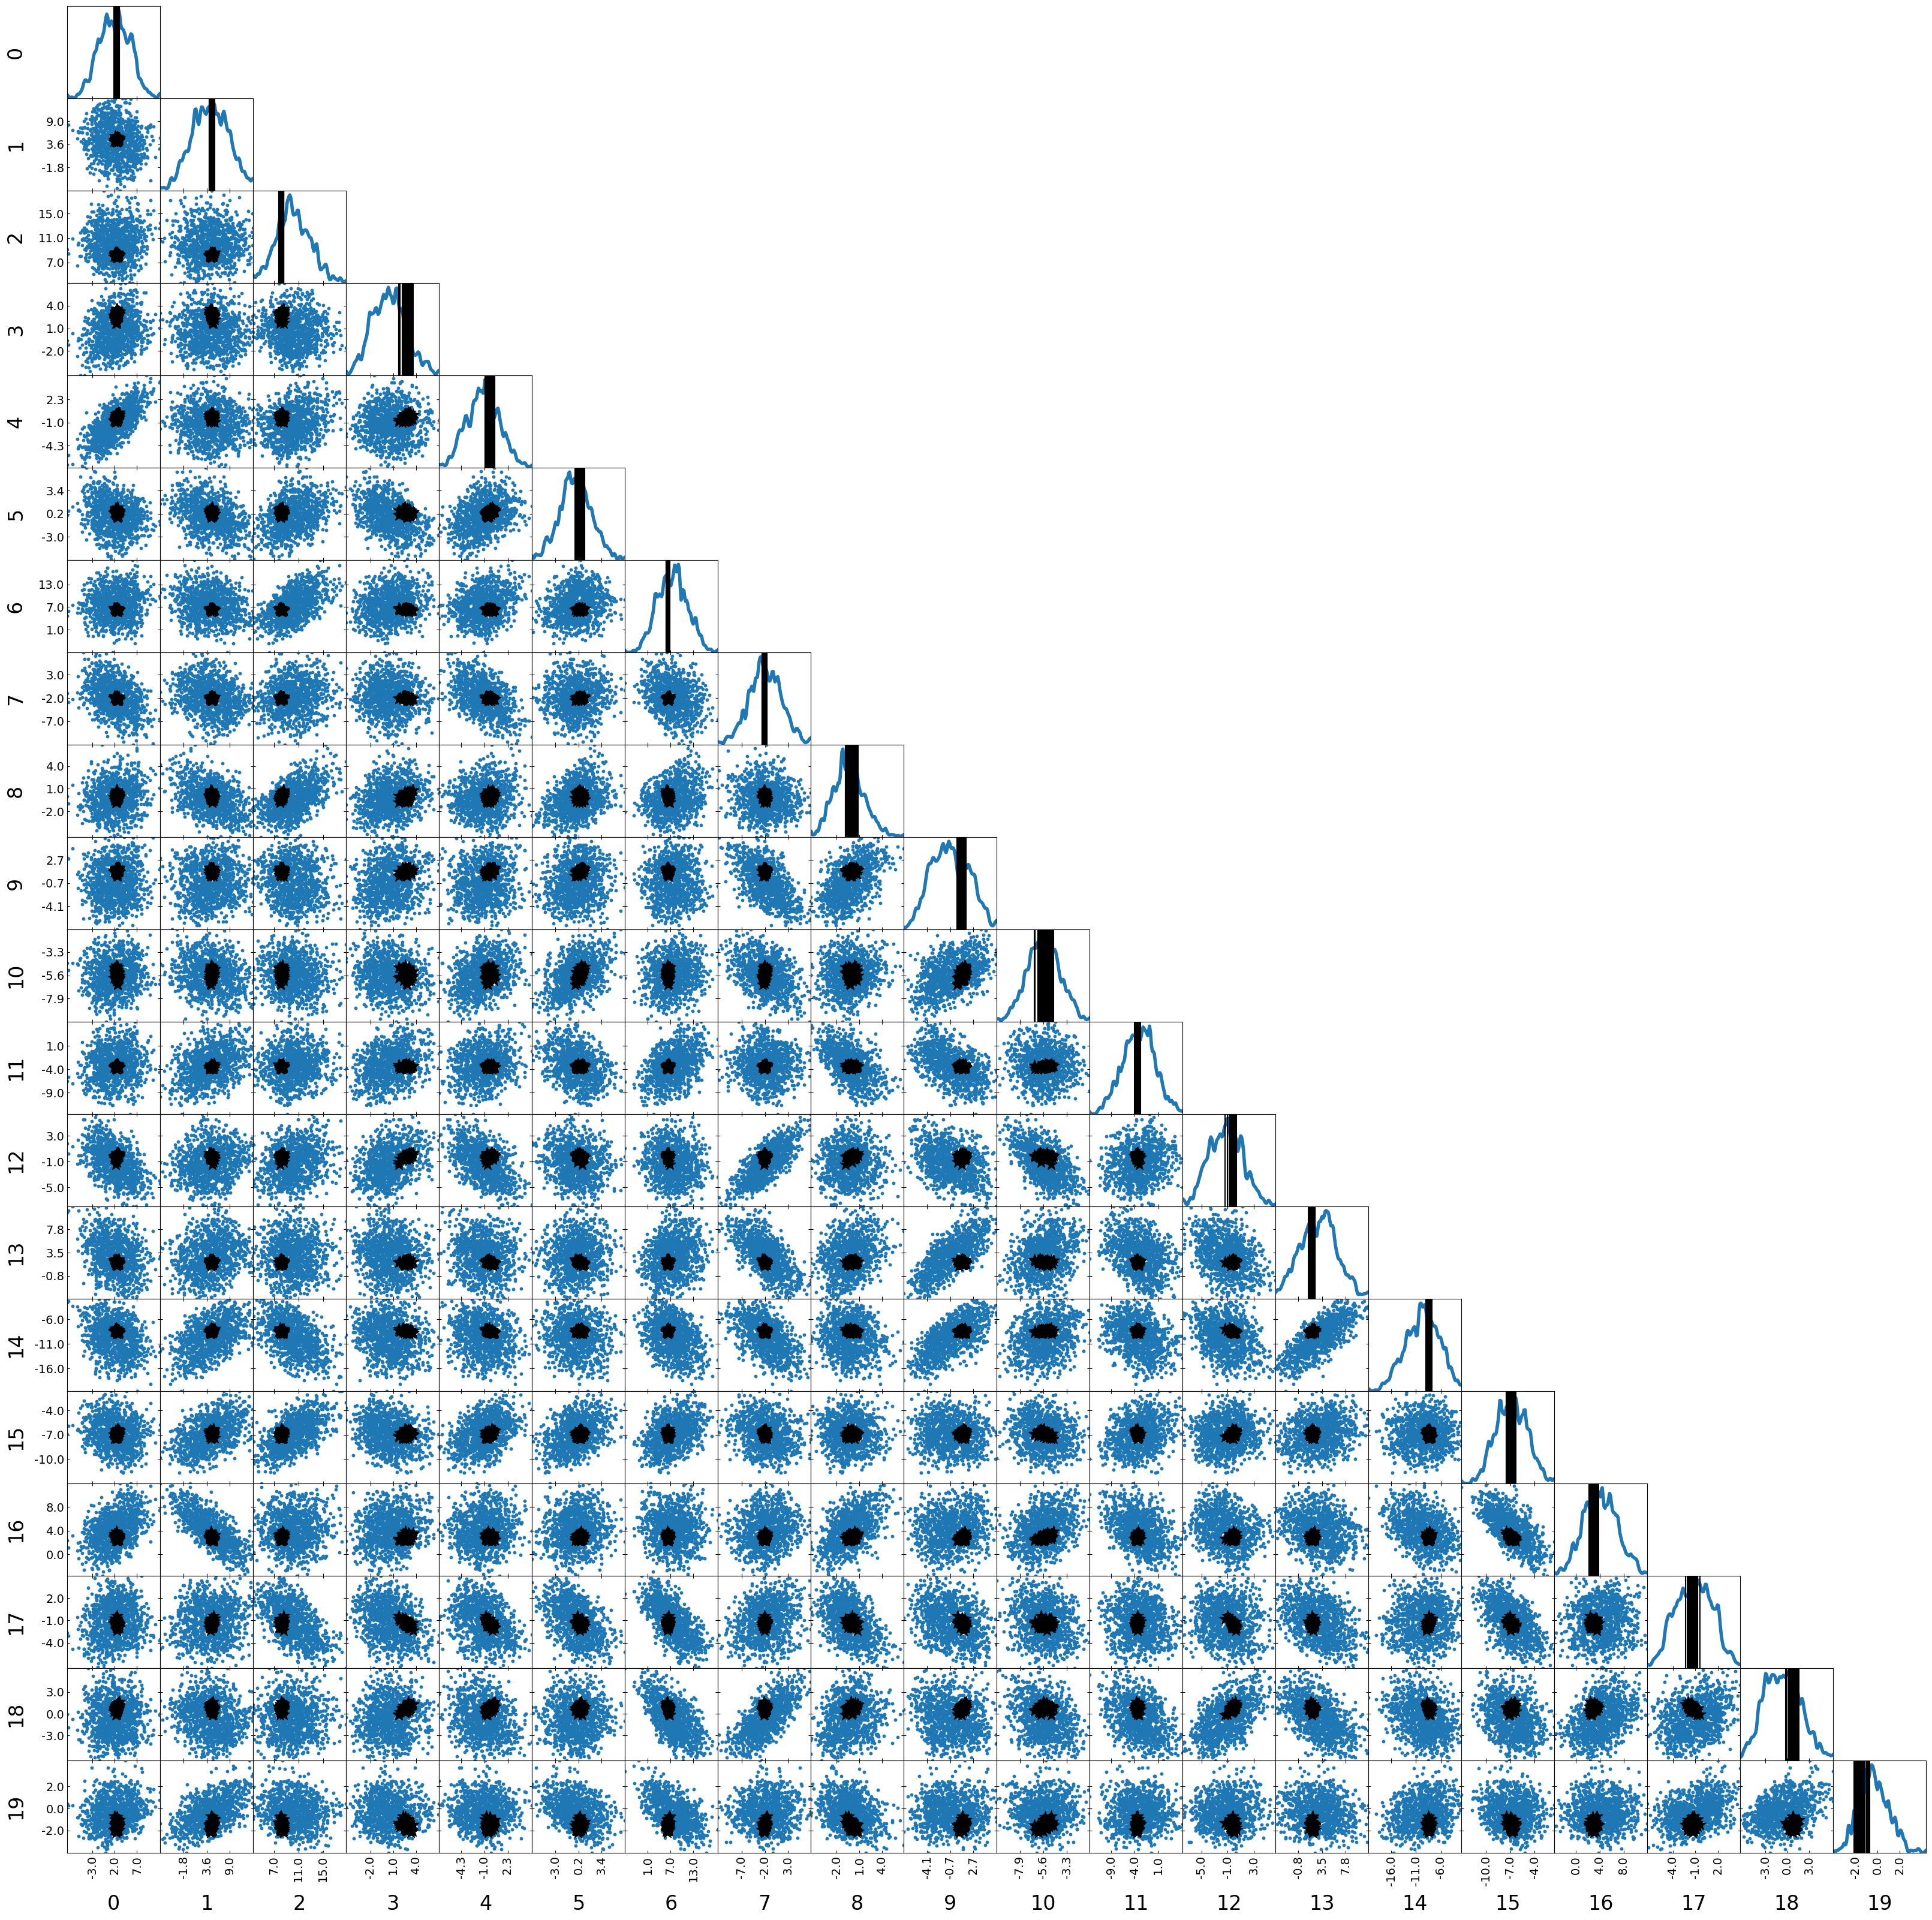

In [10]:
plot_diagnostics = True

for obs_label, obs_file in zip(obs_labels, obs_files):
    print(f"CosmoGrid mock: {obs_label}")
    
    with h5py.File(obs_file, "r") as f_in:
        obs_maps = f_in["obs/maps"][:]
        print("obs_maps.shape =", obs_maps.shape)

    # select
    if obs_maps.shape[-1] == n_z_lensing + n_z_clustering:
        if with_lensing and not with_clustering:
            obs_maps = obs_maps[:,:,:n_z_lensing]
        if with_clustering and not with_lensing:
            obs_maps = obs_maps[:,:,n_z_clustering:]
    
    # normalize
    if with_lensing and with_clustering:
        obs_maps[:,:,:n_z_lensing] /= msfm_conf["analysis"]["normalization"]["lensing"]
        obs_maps[:,:,n_z_lensing:] /= msfm_conf["analysis"]["normalization"]["clustering"]
    elif with_lensing:
        obs_maps[:,:] /= msfm_conf["analysis"]["normalization"]["lensing"]
    elif with_clustering:
        obs_maps[:,:] /= msfm_conf["analysis"]["normalization"]["clustering"]

    batch_size = 10
    obs_preds = []
    for start in tqdm(range(0, obs_maps.shape[0], batch_size)):
        end = start + batch_size
        obs_preds.append(model(downsample_map(obs_maps[start:end]), training=False).numpy())
    obs_preds = np.concatenate(obs_preds, axis=0)
    assert obs_preds.shape[0] == obs_maps.shape[0]
    
    if plot_diagnostics:
        evaluation.plot_summary_space_prior_predictive(grid_preds, obs_preds)    

    # save
    evaluation.append_obs_to_file(pred_file,  f"obs/preds/{obs_label}_stack", obs_preds)
    evaluation.append_obs_to_file(pred_file,  f"obs/preds/{obs_label}_mean", np.mean(obs_preds, axis=0))

    evaluation.append_obs_to_file(pred_file, f"obs/cosmos/{obs_label}", parameters.get_fiducials(params, msfm_conf))

## DES Y3

26-05-15 09:00:25   catalog.py INF   Loaded metacal maps from cache 
26-05-15 09:00:25   catalog.py INF   Loaded maglim map from cache 
26-05-15 09:00:27 observation. INF   Forward modeling the weak lensing map 
26-05-15 09:00:29 observation. INF   Forward modeling the galaxy clustering map 
26-05-15 09:00:29 observation. WAR   Applying maglim systematics map 


W0000 00:00:1778828431.527086   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527224   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527315   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527410   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527503   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527589   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527675   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527760   81928 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778828431.527847   81928 gp

wrote obs/preds/DESy3 of shape (20,)


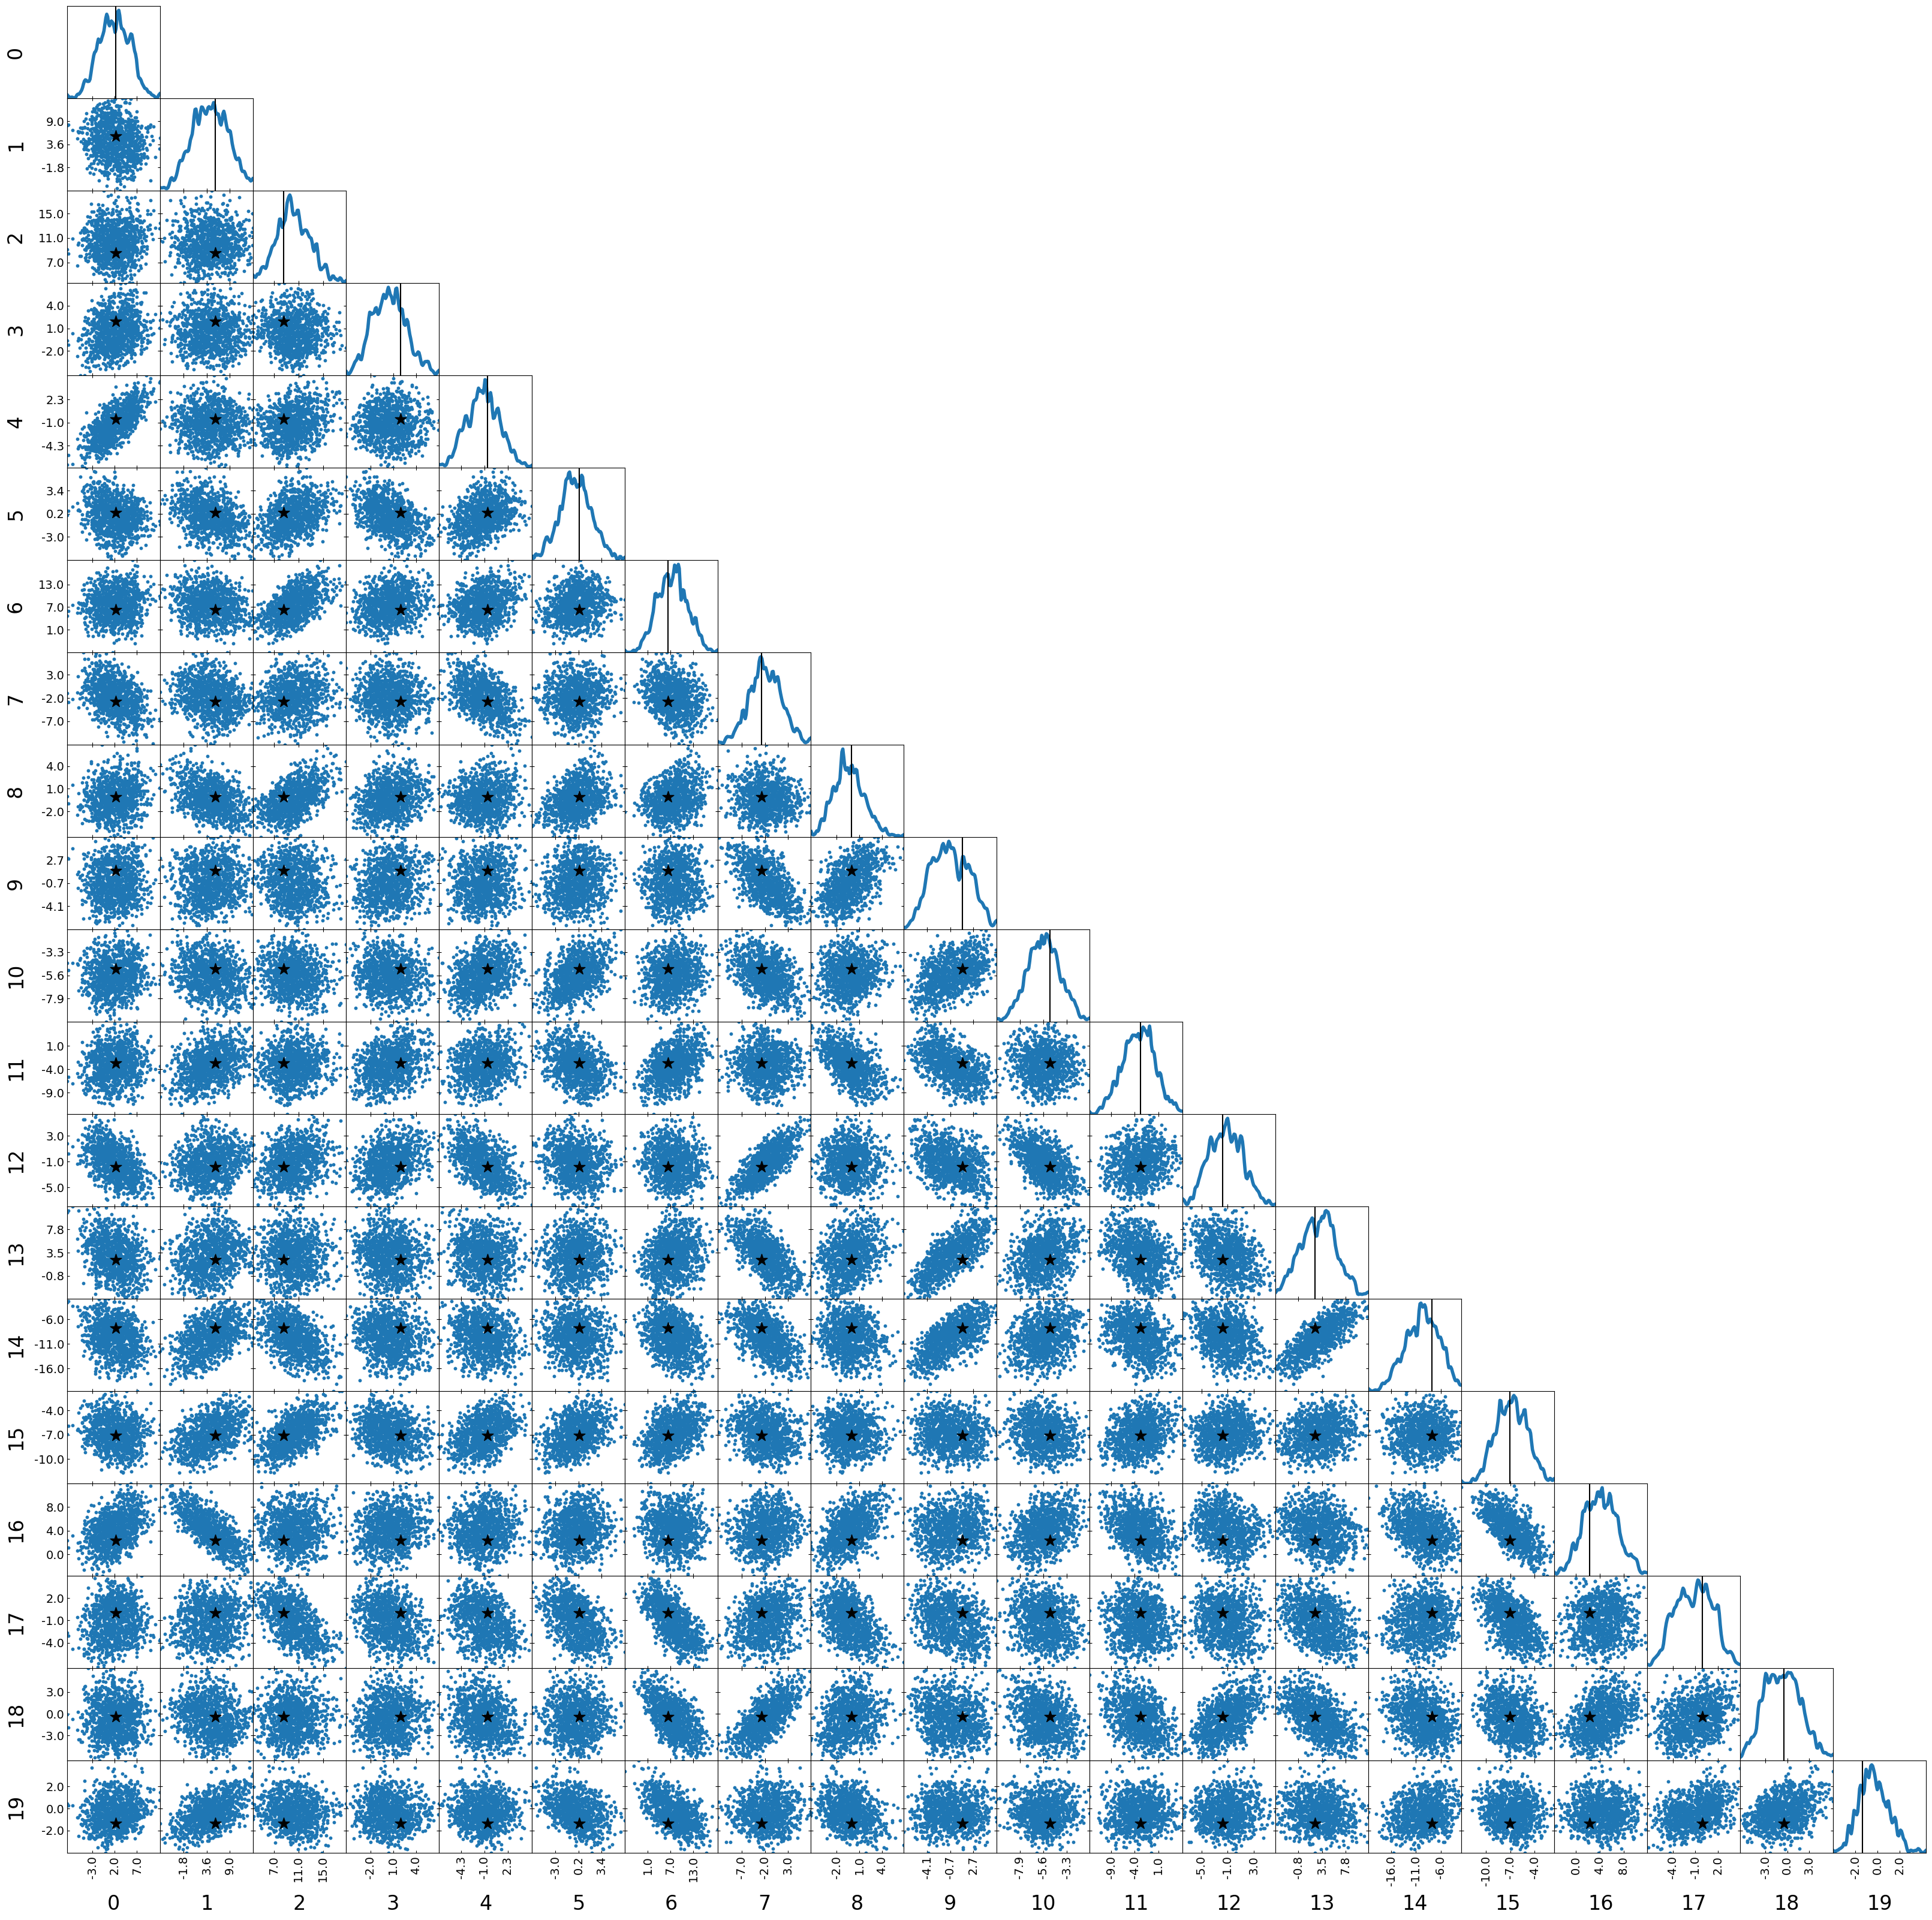

In [11]:
wl_gamma_map = None
gc_count_map = None
if with_lensing:
    wl_gamma_map, _ = catalog.build_metacal_map_from_cat(msfm_conf)
if with_clustering:
    gc_count_map = catalog.build_maglim_map_from_cat(msfm_conf)

des_dv, _, pix = observation.forward_model_observation_map(
    wl_gamma_map=wl_gamma_map,
    gc_count_map=gc_count_map,
    conf=msfm_conf,
    apply_norm=True,
    with_padding=True,
    nest_in=False,
    apply_maglim_sys_map=True,
)

des_pred = model(downsample_map(des_dv[np.newaxis]), training=False).numpy()
evaluation.plot_summary_space_prior_predictive(grid_preds, des_pred)

des_label = f"obs/preds/DESy3"
evaluation.append_obs_to_file(pred_file, des_label, des_pred)

In [12]:
# des_dv, _, pix = observation.forward_model_observation_map(
#     wl_gamma_map=wl_gamma_map,
#     gc_count_map=gc_count_map,
#     conf=msfm_conf,
#     apply_norm=True,
#     with_padding=True,
#     nest_in=False,
#     apply_maglim_sys_map=False,
# )

# des_pred = model(downsample_map(des_dv[np.newaxis]), training=False).numpy()
# evaluation.plot_summary_space_prior_predictive(grid_preds, des_pred)

# des_label = f"obs/preds/DESy3_no_sys"
# evaluation.append_obs_to_file(pred_file, des_label, des_pred)

In [13]:
# sign_combinations = [(1, 1), (-1, 1), (1, -1), (-1, -1)]

# for sign_e1, sign_e2 in sign_combinations:
#     sign_label = f"e1{'p' if sign_e1 > 0 else 'm'}_e2{'p' if sign_e2 > 0 else 'm'}"

#     _wl_gamma_map = None
#     if with_lensing:
#         _wl_gamma_map, _ = catalog.build_metacal_map_from_cat(
#             msfm_conf, debug=False, sign_e1=sign_e1, sign_e2=sign_e2
#         )

#     des_dv, _, pix = observation.forward_model_observation_map(
#         wl_gamma_map=_wl_gamma_map,
#         gc_count_map=gc_count_map,
#         conf=msfm_conf,
#         apply_norm=True,
#         with_padding=True,
#         nest_in=False,
#         apply_maglim_sys_map=False,
#     )

#     des_pred = model(downsample_map(des_dv[np.newaxis]), training=False).numpy()
#     evaluation.plot_summary_space_prior_predictive(grid_preds, des_pred)

#     evaluation.append_obs_to_file(pred_file, f"obs/preds/DESy3_{sign_label}", des_pred)


## Buzzard

In [14]:
def evaluate_buzzard(
    obs_label, 
    lensing_file=None, 
    clustering_file=None, 
    lensing=False, 
    clustering=False,
    combined=False,
    nest_in=False,
    plot_diagnostics=False
):
    # load the map
    wl_map = None
    gc_map = None
    if lensing or combined:
        wl_map = buzzard.get_lensing_map(lensing_file, plot_diagnostics=plot_diagnostics)
    if clustering or combined:
        gc_map = buzzard.get_clustering_map(clustering_file, plot_diagnostics=plot_diagnostics)

    # forward model
    obs_map, _, _ = observation.forward_model_observation_map(
        wl_gamma_map=wl_map,
        gc_count_map=gc_map,
        conf=msfm_conf,
        apply_norm=True,
        with_padding=True,
        nest_in=nest_in,
    )

    # evaluate
    obs_pred = model(downsample_map(obs_map[np.newaxis]), training=False).numpy()
    print(obs_label, ": obs_pred =", obs_pred)

    if plot_diagnostics:
        plot_summary_space_prior_predictive(obs_pred)

    # save
    evaluation.append_obs_to_file(obs_label, obs_pred)

In [15]:
# buzzard_indices, lensing_files, clustering_files = buzzard.get_filenames()

# lensing_files = lensing_files[:2]

# for i, lensing_file, clustering_file in zip(buzzard_indices, lensing_files, clustering_files):
#     obs_label = f"obs/preds/Buzzard_{i}"
    
#     evaluate_buzzard(
#         obs_label, 
#         lensing_file, 
#         clustering_file, 
#         lensing=lensing,
#         clustering=clustering,
#         combined=combined,
#         # plot_diagnostics=True
#     )
